**Vision Transformer - ViT** paper'ı : https://arxiv.org/abs/2010.11929

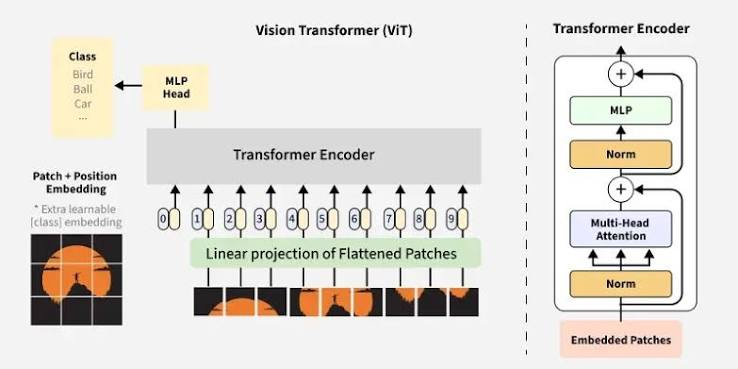

# Vision Transformer (ViT) Mimarisi ve Çalışma Mantığı

Doğal Dil İşleme (NLP) dünyasında standart haline gelen **Transformer** mimarisini Computer Vision alanına doğrudan uyarlayan çığır açıcı yaklaşım: **"An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale"** (Dosovitskiy ve ark., 2020)[cite: 1].

Klasik Convolutional Neural Networks (CNN) modelleri yerel pikseller üzerinde convolution işlemleriyle inductive bias (yerellik ve öteleme değişmezliği) kurarken; ViT bir görseli tıpkı bir cümledeki kelimeler gibi dizi (sequence) haline getirir[cite: 1]. Böylece tüm pikseller arasındaki küresel ilişkileri standart **Transformer Encoder** bloklarıyla doğrudan öğrenir[cite: 1].

---

## Mimarinin Genel Akışı (Aşağıdan Yukarıya)

### 1. Görseli Patch'lere Ayırma (Patchify)
* Standart bir 2D görsel tensörü $H \times W \times C$ boyutlarındadır (örneğin $224 \times 224 \times 3$)[cite: 1].
* Görsel, $P \times P$ boyutunda (genellikle $16 \times 16$) örtüşmeyen küçük ızgaralara (patch'lere) bölünür[cite: 1].
* Toplam patch sayısı ($N$):
  $$N = \frac{H \times W}{P^2} = \frac{224 \times 224}{16^2} = 196$$
* Her bir patch düzleştirildiğinde (flatten) $P^2 \cdot C$ uzunluğunda (örneğin $16 \times 16 \times 3 = 768$) 1D bir vektöre dönüşür.

---

### 2. Linear Projection of Flattened Patches (Patch Embedding)
* Flatten edilen 196 adet patch, öğrenilebilir bir projeksiyon matrisiyle Transformer'ın gizli boyutu olan embedding dimension ($D = 768$) uzayına yansıtılır[cite: 1].
* **Uygulama Notu:** Kod tarafında bu adım, `kernel_size=patch_size` ve `stride=patch_size` parametrelerine sahip bir `nn.Conv2d` katmanı kullanılarak çok daha verimli şekilde gerçekleştirilir.
* Bu adımdan sonra tensör boyutu: $[N, D] \rightarrow [196, 768]$ olur[cite: 1].

---

### 3. Class Token (Extra Learnable `[class]` Embedding)
* BERT modelindeki `[CLS]` token yaklaşımı görsel sınıflandırma için birebir uyarlanmıştır[cite: 1].
* Modelin belirli bir patch yerine görselin tamamını temsil eden genel bir çıkarım yapabilmesi için, sequence'ın en başına rastgele başlatılan, eğitilebilir $1 \times 1 \times D$ boyutunda bir **Class Token** eklenir (`torch.cat`)[cite: 1].
* Sequence uzunluğu $196$'dan $197$'ye çıkar: $[batch\_size, 197, 768]$[cite: 1].

---

### 4. Position Embedding
* Self-Attention mekanizması doğası gereği yön veya sıra algısına (permutation-invariant) sahip değildir; patch'lerin uzamsal konumlarını kendiliğinden ayırt edemez.
* Patch'lerin görsel içindeki 2D koordinat düzenini korumak amacıyla her bir token vektörünün üzerine 1D öğrenilebilir bir **Position Embedding** vektörü eleman bazlı toplanarak (`+`) eklenir[cite: 1].
* Tensör boyutu değişmez: $[batch\_size, 197, 768]$[cite: 1].
* Ek olarak aşırı öğrenmeyi (overfitting) engellemek amacıyla bu aşamada tensöre **Embedding Dropout** uygulanır.

---

### 5. Transformer Encoder Blokları
Elde edilen tensör, art arda dizilmiş $L$ adet (ViT-Base için 12) Transformer Encoder bloğundan geçer[cite: 1]:
* **Pre-LayerNorm (LN):** Stabil bir eğitim süreci için her alt katmandan önce girdi tensörüne LayerNorm uygulanır.
* **Multi-Head Self-Attention (MSA):** Her bir patch'in hem diğer tüm patch'lerle hem de `[class]` token ile olan anlamsal ilişkisini hesaplar; modelin görselin farklı bölgelerine aynı anda odaklanmasını sağlar[cite: 1].
* **MLP Block (Feed-Forward Network):** İki adet Linear katmandan oluşur; aralarında GELU non-linear aktivasyonu ve Dropout bulunur. İlk katmanda boyut $D$'den $mlp\_size$'a ($768 \rightarrow 3072$) genişletilir, ikinci katmanda tekrar $D$'ye indirilir.
* **Residual Connections:** Yok olan gradyan (vanishing gradient) problemini engellemek için hem MSA hem de MLP bloklarının girişleri çıktılarına doğrudan eklenir ($x + \text{SubLayer}(x)$).

---

### 6. Classifier Head (MLP Head)
* $L$ adet Transformer Encoder bloğundan çıkan nihai tensör $[batch\_size, 197, 768]$ boyutundadır[cite: 1].
* Görseldeki tüm patch'lerin küresel bağlamını toplayan **yalnızca 0. indeksteki `[class]` token tensörü** ($z_L^0 \in \mathbb{R}^{1 \times 768}$) seçilir[cite: 1].
* Bu vektör son bir **LayerNorm** katmanından geçirilip hedef sınıf sayısı ($num\_classes$) kadar çıktı üreten bir **Linear Layer** (MLP Head) ile haritalanarak sınıflandırma logit'leri elde edilir[cite: 1].

---

## Mimarinin Matematiksel Özeti (Formüller)

1. **Girdi Temsili (Embedding Adımı):**
   $$z_0 = [x_{\text{class}}; \, x_p^1 E; \, x_p^2 E; \, \dots; \, x_p^N E] + E_{\text{pos}}, \quad E \in \mathbb{R}^{(P^2 \cdot C) \times D}, \, E_{\text{pos}} \in \mathbb{R}^{(N + 1) \times D}$$
   *Flatten edilmiş görsel patch'leri ($x_p$) lineer projeksiyon matrisi ($E$) ile $D$ boyutuna yansıtılır[cite: 1]. Dizi ekseninin başına eğitilebilir sınıf vektörü ($x_{\text{class}}$) eklenir ve uzamsal bilgiyi korumak için her bir token'a konum vektörleri ($E_{\text{pos}}$) toplanarak eklenir[cite: 1].*

2. **Transformer Blokları ($l = 1 \dots L$):**
   $$z'_l = \text{MSA}(\text{LN}(z_{l-1})) + z_{l-1}$$
   $$z_l = \text{MLP}(\text{LN}(z'_l)) + z'_l$$
   *Her blokta Pre-LN mimarisi uygulanır; tensör önce LayerNorm'dan geçer, ardından Multi-Head Self-Attention (MSA) ve MLP katmanları çalıştırılır. Gradyan akışını güçlendirmek için her iki alt katmanda da residual connection ile önceki adımın girdisi doğrudan toplanır.*

3. **Nihai Tahmin (Classifier Head):**
   $$y = \text{LN}(z_L^0) W_{\text{head}}$$
   *Son Encoder bloğundan çıkan tensörün yalnızca 0. indeksindeki `[class]` token temsilcisi ($z_L^0$) çekilir[cite: 1]. Son bir LayerNorm'un ardından sınıflandırma matrisi ($W_{\text{head}}$) ile çarpılarak hedef sınıfların logit değerleri üretilir[cite: 1].*

In [ ]:
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
!pip install torchinfo
from torchvision import transforms, datasets
from torchinfo import summary
from torch.utils.data import DataLoader, Subset

In [2]:
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
device

'cuda'

In [3]:
IMG_SIZE = 224
seed = 42

In [4]:
def to_rgb(img):
  """Herhangi bir PIL görüntüsünü 3 kanallı RGB'ye dönüştürün (bazı Caltech101 görüntüleri gri tonlamalıdır)"""
  return img.convert("RGB")

In [5]:
# transforms

train_tf = transforms.Compose([
    transforms.Lambda(to_rgb),  # grayscale -> RGB
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0), ratio=(0.75, 1.33)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15), ratio=(0.3, 3.3), value="random"),
])

test_tf = transforms.Compose([
    transforms.Lambda(to_rgb),
    transforms.Resize(256),            # aspect ratio-en boy oranı korunsun
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])

In [6]:
from torch.utils.data import random_split
root = "./data"
test_ratio = 0.2

# Dataset - 2 ayrı instance
ds_train_full = datasets.Caltech101(root=root, download=True, transform=train_tf)
ds_test_full = datasets.Caltech101(root=root, download=True, transform=test_tf)

100%|██████████| 137M/137M [00:07<00:00, 19.1MB/s]


In [7]:
# SPLIT için index üret (reproducible)
n_total = len(ds_train_full)
n_test = int(n_total * test_ratio)
n_train = n_total - n_test

g = torch.Generator().manual_seed(seed)
perm = torch.randperm(n_total, generator=g).tolist()

train_idx = perm[:n_train]
test_idx  = perm[n_train:]

# SUBSET oluştur (aynı index, farklı transform)
train_ds = Subset(ds_train_full, train_idx)
test_ds  = Subset(ds_test_full,  test_idx)

In [8]:
n_total, len(train_ds), len(test_ds)

(8677, 6942, 1735)

In [9]:
BATCH_SIZE = 32
train_dataloader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader   = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

In [10]:
# sınıf adları
print(ds_train_full.categories)

['Faces', 'Faces_easy', 'Leopards', 'Motorbikes', 'accordion', 'airplanes', 'anchor', 'ant', 'barrel', 'bass', 'beaver', 'binocular', 'bonsai', 'brain', 'brontosaurus', 'buddha', 'butterfly', 'camera', 'cannon', 'car_side', 'ceiling_fan', 'cellphone', 'chair', 'chandelier', 'cougar_body', 'cougar_face', 'crab', 'crayfish', 'crocodile', 'crocodile_head', 'cup', 'dalmatian', 'dollar_bill', 'dolphin', 'dragonfly', 'electric_guitar', 'elephant', 'emu', 'euphonium', 'ewer', 'ferry', 'flamingo', 'flamingo_head', 'garfield', 'gerenuk', 'gramophone', 'grand_piano', 'hawksbill', 'headphone', 'hedgehog', 'helicopter', 'ibis', 'inline_skate', 'joshua_tree', 'kangaroo', 'ketch', 'lamp', 'laptop', 'llama', 'lobster', 'lotus', 'mandolin', 'mayfly', 'menorah', 'metronome', 'minaret', 'nautilus', 'octopus', 'okapi', 'pagoda', 'panda', 'pigeon', 'pizza', 'platypus', 'pyramid', 'revolver', 'rhino', 'rooster', 'saxophone', 'schooner', 'scissors', 'scorpion', 'sea_horse', 'snoopy', 'soccer_ball', 'stapler

In [11]:
print("Sınıf Sayısı:", len(ds_train_full.categories))

Sınıf Sayısı: 101


In [12]:
img, label = ds_train_full[1000]

print("Etiket:", label)
print("Sınıf Adı:", ds_train_full.categories[label])

Etiket: 2
Sınıf Adı: Leopards


In [13]:
class_names = ds_train_full.categories

In [14]:
# --- patch_embeddings ---

In [15]:
# Makaleye uygun olarak yama (patch) gömmelerini hesapla
height = 224          # Y (H): "Eğitim çözünürlüğü 224'tür."
width = 224           # G (W): Görsel genişliği
color_channels = 3    # K (C): Renk kanalı sayısı (RGB)
patch_size = 16       # P: Her bir yamanın boyutu (kenar uzunluğu)

# Toplam yama sayısını (N) hesapla
number_of_patches = int((height * width) / patch_size**2)

print(f"Görsel yüksekliği (Y={height}), genişliği (G={width}) ve yama boyutu (P={patch_size}) için toplam yama sayısı (N): {number_of_patches}")

Görsel yüksekliği (Y=224), genişliği (G=224) ve yama boyutu (P=16) için toplam yama sayısı (N): 196


In [16]:
# Girdi boyutu (tek bir görselin tensör boyutu: Yükseklik, Genişlik, Kanal)
embedding_layer_input_shape = (height, width, color_channels)

# Çıktı boyutu (Yama sayısı x Düzleştirilmiş yama vektör uzunluğu: N x (P^2 * C))
embedding_layer_output_shape = (number_of_patches, patch_size**2 * color_channels)

print(f"Girdi boyutu (tek bir 2B görsel): {embedding_layer_input_shape}")
print(f"Çıktı boyutu (yamalara ayrılıp düzleştirilmiş tek görsel): {embedding_layer_output_shape}")

Girdi boyutu (tek bir 2B görsel): (224, 224, 3)
Çıktı boyutu (yamalara ayrılıp düzleştirilmiş tek görsel): (196, 768)


In [17]:
# Bu yapı ViT makalesiyle birebir uyumludur
# Yamalama (patching) işleminin matplotlib'de nasıl görüneceğine bakalım.
# Bu kod parçasını kopyalayıp yapıştırabilirsiniz; nihai model kodunda bunu doğrudan kullanmayacağız.
image_batch, label_batch = train_dataloader.dataset[999]

# Yığından (batch) tek bir görsel ve etiketini al
image, label = image_batch, label_batch

# Görsel tensörünün ve etiketinin boyutlarını incele
image.shape, label

(torch.Size([3, 224, 224]), 59)

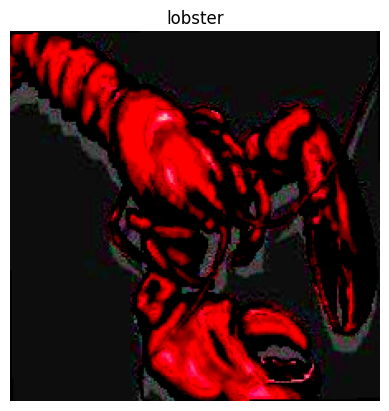

In [18]:
plt.imshow(image.permute(1, 2, 0))
plt.title(class_names[label])
plt.axis(False);

Satır başına düşen yama sayısı: 14
Sütun başına düşen yama sayısı: 14
Toplam yama sayısı: 196
Patch boyutu: 16 piksel x 16 piksel


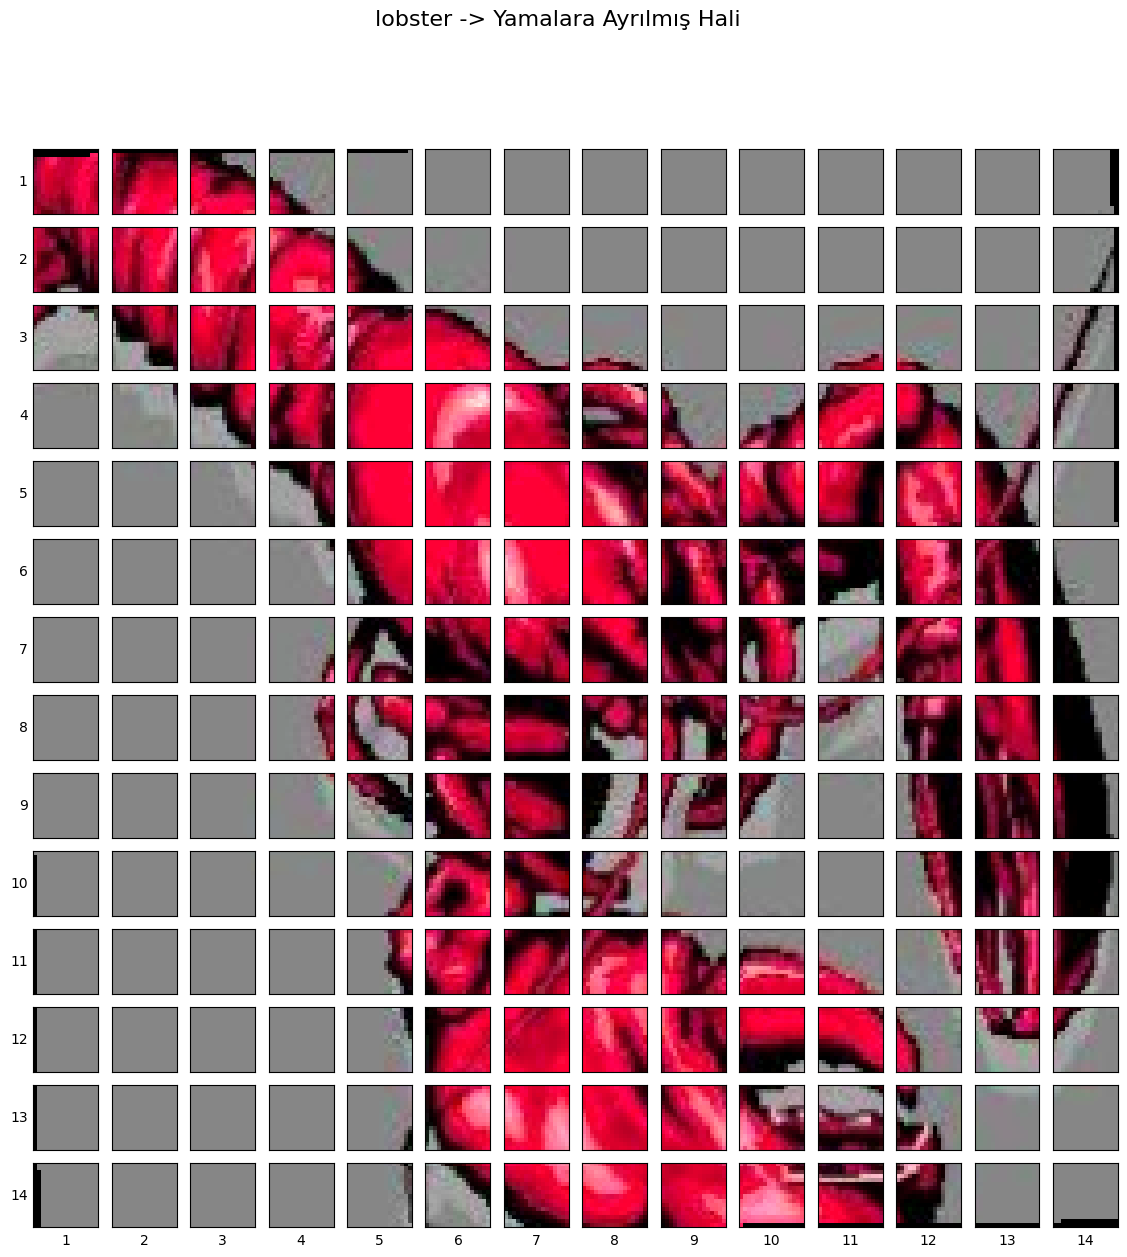

In [19]:
# Görüntü tensörünü (Kanal, Yükseklik, Genişlik) -> (Yükseklik, Genişlik, Kanal) sırasına çevir
image_permuted = image.permute(1, 2, 0)

# Matplotlib için piksel değerlerini [0, 1] aralığına ölçekle (Warning uyarısını önler ve görseli netleştirir)
image_normalized = (image_permuted - image_permuted.min()) / (image_permuted.max() - image_permuted.min())

img_size = 224
patch_size = 16
num_patches = int(img_size / patch_size)

# Görsel boyutunun yama boyutuna tam bölündüğünden emin ol
assert img_size % patch_size == 0, "Görsel boyutu yama boyutuna tam bölünmelidir."

print(f"Satır başına düşen yama sayısı: {num_patches}\n"
      f"Sütun başına düşen yama sayısı: {num_patches}\n"
      f"Toplam yama sayısı: {num_patches * num_patches}\n"
      f"Patch boyutu: {patch_size} piksel x {patch_size} piksel")

# Alt çizim ızgarasını (subplot grid) oluştur
fig, axs = plt.subplots(
    nrows=num_patches,
    ncols=num_patches,
    figsize=(num_patches, num_patches),
    sharex=True,
    sharey=True
)

# Görselin yükseklik ve genişliği üzerinde yamalar halinde ilerle
for i, patch_height in enumerate(range(0, img_size, patch_size)):
    for j, patch_width in enumerate(range(0, img_size, patch_size)):

        # İlgili yamayı çizdir (Yükseklik, Genişlik, Renk Kanalları)
        axs[i, j].imshow(image_normalized[patch_height:patch_height+patch_size,
                                          patch_width:patch_width+patch_size,
                                          :])

        # Eksen etiketlerini ve kenar boşluklarını düzenle, gereksiz çentikleri kaldır
        axs[i, j].set_ylabel(i + 1,
                             rotation="horizontal",
                             horizontalalignment="right",
                             verticalalignment="center")
        axs[i, j].set_xlabel(j + 1)
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])
        axs[i, j].label_outer()

# Ana başlığı ekle
fig.suptitle(f"{class_names[label]} -> Yamalara Ayrılmış Hali", fontsize=16)
plt.show()

In [20]:
# Yama (patch) boyutunu belirle
patch_size = 16

# ViT makalesindeki hiperparametrelerle Conv2d katmanını oluştur
conv2d = nn.Conv2d(
    in_channels=3,            # Giriş renk kanalı sayısı (RGB için 3)
    out_channels=768,         # Tablo 1'deki Gizli Boyut (D): Gömme (embedding) vektör uzunluğu
    kernel_size=patch_size,   # Çekirdek boyutu (patch_size, patch_size) olarak da yazılabilir
    stride=patch_size,        # Kaydırma adımı (yamaların birbiriyle örtüşmemesi için patch_size kadar)
    padding=0                 # Kenar dolgusu yok
)

# Görsele yığın (batch) boyutu ekleyerek evrişim katmanından geçir:
# (Kanal, Yükseklik, Genişlik) -> (Yığın, Kanal, Yükseklik, Genişlik)
image_out_of_conv = conv2d(image.unsqueeze(0))
print(image_out_of_conv.shape)

torch.Size([1, 768, 14, 14])


In [21]:
# Düzleştirme (Flatten) katmanını oluştur:
# Sadece uzamsal boyutları (14x14) tek bir boyutta (196 yama) birleştirmek için
flatten = nn.Flatten(
    start_dim=2,  # Öznitelik haritası yüksekliğini düzleştirmeye başla (2. boyut)
    end_dim=3     # Öznitelik haritası genişliğini düzleştirmeyi bitir (3. boyut)
)

Orijinal görsel boyutu: torch.Size([3, 224, 224])
Evrişim sonrası öznitelik haritası boyutu: torch.Size([1, 768, 14, 14])
Düzleştirilmiş öznitelik haritası boyutu: torch.Size([1, 768, 196])


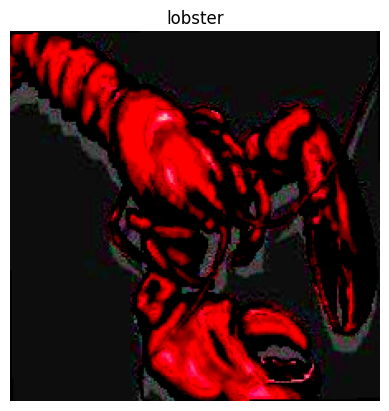

In [22]:
# 1. Tek bir orijinal görseli görselleştir
plt.imshow(image.permute(1, 2, 0))  # Matplotlib için eksenleri (Yükseklik, Genişlik, Kanal) sırasına getir
plt.title(class_names[label])
plt.axis(False)
print(f"Orijinal görsel boyutu: {image.shape}")

# 2. Görseli evrişim katmanıyla öznitelik haritalarına (feature maps) dönüştür
# Boyut hatası almamak için yığın boyutu (unsqueeze(0)) eklenir
image_out_of_conv = conv2d(image.unsqueeze(0))
print(f"Evrişim sonrası öznitelik haritası boyutu: {image_out_of_conv.shape}")

# 3. Uzamsal öznitelik haritalarını düzleştirerek yama dizisi haline getir
image_out_of_conv_flattened = flatten(image_out_of_conv)
print(f"Düzleştirilmiş öznitelik haritası boyutu: {image_out_of_conv_flattened.shape}")

In [23]:
# Flatten edilmiş patch embedding'leri Transformer mimarisine uygun boyut sırasına getir
# [batch_size, embedding_dim, num_patches] -> [batch_size, num_patches, embedding_dim]
image_out_of_conv_flattened_reshaped = image_out_of_conv_flattened.permute(0, 2, 1)

print(f"Patch embedding dizi boyutu: {image_out_of_conv_flattened_reshaped.shape} -> [batch_size, num_patches, embedding_dim]")
# Patch embedding dizi boyutu: torch.Size([1, 196, 768]) -> [batch_size, num_patches, embedding_dim]

Patch embedding dizi boyutu: torch.Size([1, 196, 768]) -> [batch_size, num_patches, embedding_dim]


In [24]:
# Tüm bu adımları tek bir modüler katman altında toplayalım

# 1. nn.Module sınıfından türetilen özel bir katman sınıfı tanımla
class PatchEmbedding(nn.Module):
    # 2. Katmanı uygun hiperparametrelerle başlat
    def __init__(self,
                 in_channels: int = 3,
                 patch_size: int = 16,
                 embedding_dim: int = 768):
        super().__init__()

        self.patch_size = patch_size

        # 3. Görseli patch'lere ayıran ve her patch'i embedding vektörüne yansıtan conv katmanı
        self.patcher = nn.Conv2d(in_channels=in_channels,
                                 out_channels=embedding_dim,
                                 kernel_size=patch_size,
                                 stride=patch_size,
                                 padding=0)

        # 4. Feature map'in uzamsal boyutlarını (14x14) tek bir dizi boyutuna (196) düzleştiren katman
        self.flatten = nn.Flatten(start_dim=2,  # Yükseklik ve genişlik eksenlerini düzleştir
                                  end_dim=3)

    # 5. İleri besleme (forward pass) metodunu tanımla
    def forward(self, x):
        # Giriş çözünürlüğünün patch boyutuna tam bölünebildiğini kontrol et
        image_resolution = x.shape[-1]
        assert image_resolution % self.patch_size == 0, (
            f"Girdi görsel boyutu patch boyutuna tam bölünmelidir! "
            f"Görsel boyutu: {image_resolution}, Patch boyutu: {self.patch_size}"
        )

        # Katmanları sırayla çalıştır
        x_patched = self.patcher(x)
        x_flattened = self.flatten(x_patched)

        # 6. Çıktı tensörünü Transformer sırasına sok (Embedding boyutu en son eksende olmalı):
        # [batch_size, embedding_dim, num_patches] -> [batch_size, num_patches, embedding_dim]
        return x_flattened.permute(0, 2, 1)

In [25]:
# Katmanı örnekle (instance oluştur)
patchify = PatchEmbedding(in_channels=3,
                          patch_size=16,
                          embedding_dim=768)

# Tek bir görseli katmandan geçir (0. indekse batch boyutu eklenmezse hata verir)
print(f"Girdi görsel boyutu: {image.unsqueeze(0).shape}")
patch_embedded_image = patchify(image.unsqueeze(0))
print(f"Çıktı patch embedding boyutu: {patch_embedded_image.shape}")

# Girdi görsel boyutu: torch.Size([1, 3, 224, 224])
# Çıktı patch embedding boyutu: torch.Size([1, 196, 768])

Girdi görsel boyutu: torch.Size([1, 3, 224, 224])
Çıktı patch embedding boyutu: torch.Size([1, 196, 768])


In [26]:
# Şimdi rastgele boyutlandırılmış bir tensörle model özetini (summary) test edelim
# Rastgele girdi boyutu: (batch_size, channels, height, width)
random_input_image = (1, 3, 224, 224)

# Katmanın girdi-çıktı boyutlarını ve eğitilebilir parametrelerini listele
summary(PatchEmbedding(),
        input_size=random_input_image,  # Boyut uyumu testi için
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
PatchEmbedding (PatchEmbedding)          [1, 3, 224, 224]     [1, 196, 768]        --                   True
├─Conv2d (patcher)                       [1, 3, 224, 224]     [1, 768, 14, 14]     590,592              True
├─Flatten (flatten)                      [1, 768, 14, 14]     [1, 768, 196]        --                   --
Total params: 590,592
Trainable params: 590,592
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 115.76
Input size (MB): 0.60
Forward/backward pass size (MB): 1.20
Params size (MB): 2.36
Estimated Total Size (MB): 4.17

In [27]:
# Şimdi token embedding'leri oluşturalım
print(patch_embedded_image)
print(f"Patch embedding boyutu: {patch_embedded_image.shape} -> [batch_size, num_patches, embedding_dim]")

tensor([[[-0.2791, -0.5649, -0.2414,  ..., -1.0907, -0.4352,  0.0752],
         [-0.1393, -0.2058,  0.0077,  ..., -1.6449, -0.0650,  0.2464],
         [-0.5624, -0.3601,  0.1307,  ..., -1.3412, -0.2953, -0.0447],
         ...,
         [ 0.1219, -0.5286, -0.4632,  ..., -0.7840, -0.2120,  0.0734],
         [-0.0059, -0.1231, -0.2779,  ...,  0.2002, -0.0546, -0.0934],
         [ 0.0668, -0.1279, -0.4782,  ...,  0.1935, -0.1000, -0.1658]]],
       grad_fn=<PermuteBackward0>)
Patch embedding boyutu: torch.Size([1, 196, 768]) -> [batch_size, num_patches, embedding_dim]


In [28]:
# Batch size ve embedding dimension (D) değerlerini al
batch_size = patch_embedded_image.shape[0]
embedding_dimension = patch_embedded_image.shape[-1]

# Embedding boyutuyla (D) aynı uzunluğa sahip eğitilebilir class token ([class]) oluştur
class_token = nn.Parameter(
    torch.ones(batch_size, 1, embedding_dimension),  # [batch_size, token_count, embedding_dimension]
    requires_grad=True                               # Parametrenin geri yayılımda güncellenmesini sağla
)

# Class token'ın ilk 10 değerini göster
print(class_token[:, :, :10])

# Class token'ın tensör boyutunu yazdır
print(f"Class token boyutu: {class_token.shape} -> [batch_size, token_count, embedding_dimension]")

tensor([[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]], grad_fn=<SliceBackward0>)
Class token boyutu: torch.Size([1, 1, 768]) -> [batch_size, token_count, embedding_dimension]


In [29]:
# Class token'ı patch embedding dizisinin en başına ekle (dizi ekseninde birleştirme)
patch_embedded_image_with_class_embedding = torch.cat(
    (class_token, patch_embedded_image),
    dim=1  # 1. eksen (token/patch dizisi boyutu) üzerinden birleştir
)

# Class token eklenmiş patch embedding dizisini ve güncel tensör boyutunu yazdır (196 + 1 = 197 token)
print(patch_embedded_image_with_class_embedding)
print(
    f"Class token eklenmiş patch embedding dizisi boyutu: "
    f"{patch_embedded_image_with_class_embedding.shape} -> [batch_size, total_tokens, embedding_dimension]"
)

tensor([[[ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
         [-0.2791, -0.5649, -0.2414,  ..., -1.0907, -0.4352,  0.0752],
         [-0.1393, -0.2058,  0.0077,  ..., -1.6449, -0.0650,  0.2464],
         ...,
         [ 0.1219, -0.5286, -0.4632,  ..., -0.7840, -0.2120,  0.0734],
         [-0.0059, -0.1231, -0.2779,  ...,  0.2002, -0.0546, -0.0934],
         [ 0.0668, -0.1279, -0.4782,  ...,  0.1935, -0.1000, -0.1658]]],
       grad_fn=<CatBackward0>)
Class token eklenmiş patch embedding dizisi boyutu: torch.Size([1, 197, 768]) -> [batch_size, total_tokens, embedding_dimension]


In [30]:
# Eğitilebilir sınıf belirteci dizinin başına eklendi!
# Sırada konum gömmelerini (position embeddings) oluşturmak var

In [31]:
patch_embedded_image_with_class_embedding, patch_embedded_image_with_class_embedding.shape

# Toplam patch sayısını (N) hesapla
number_of_patches = int((height * width) / patch_size**2)

# Embedding boyutunu tensörün son ekseninden al
embedding_dimension = patch_embedded_image_with_class_embedding.shape[2]

# Eğitilebilir 1D position embedding tensörünü oluştur:
# Patch sayısına class token da dahil olduğu için (N + 1) token boyutu kullanılır
position_embedding = nn.Parameter(
    torch.ones(1, number_of_patches + 1, embedding_dimension),
    requires_grad=True  # Position embedding değerlerinin öğrenilebilir olmasını sağla
)

# İlk 10 token için ilk 10 position embedding değerini ve tensör boyutunu yazdır
print(position_embedding[:, :10, :10])
print(f"Position embedding boyutu: {position_embedding.shape} -> [1, total_tokens, embedding_dimension]")

tensor([[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]], grad_fn=<SliceBackward0>)
Position embedding boyutu: torch.Size([1, 197, 768]) -> [1, total_tokens, embedding_dimension]


In [32]:
# Position embedding'i, class token eklenmiş patch embedding tensörüne ekle (vektörel toplama)
patch_and_position_embedding = patch_embedded_image_with_class_embedding + position_embedding

print(patch_and_position_embedding)
print(
    f"Patch embedding, class token ve position embedding eklendikten sonraki nihai tensör boyutu: "
    f"{patch_and_position_embedding.shape} -> [batch_size, total_tokens, embedding_dimension]"
)

tensor([[[ 2.0000,  2.0000,  2.0000,  ...,  2.0000,  2.0000,  2.0000],
         [ 0.7209,  0.4351,  0.7586,  ..., -0.0907,  0.5648,  1.0752],
         [ 0.8607,  0.7942,  1.0077,  ..., -0.6449,  0.9350,  1.2464],
         ...,
         [ 1.1219,  0.4714,  0.5368,  ...,  0.2160,  0.7880,  1.0734],
         [ 0.9941,  0.8769,  0.7221,  ...,  1.2002,  0.9454,  0.9066],
         [ 1.0668,  0.8721,  0.5218,  ...,  1.1935,  0.9000,  0.8342]]],
       grad_fn=<AddBackward0>)
Patch embedding, class token ve position embedding eklendikten sonraki nihai tensör boyutu: torch.Size([1, 197, 768]) -> [batch_size, total_tokens, embedding_dimension]


In [33]:
# Şimdi tüm bu adımları (yama gömme + sınıf belirteci + konum gömmesi) tek bir çatı altında birleştirelim

In [34]:
# 1. patch_size değerini belirle
patch_size = 16

# 2. Orijinal görsel tensörünün boyutunu yazdır ve görsel boyutlarını (yükseklik, genişlik) al
print(f"Orijinal görsel tensörü boyutu: {image.shape}")
height, width = image.shape[1], image.shape[2]

# 3. Görsel tensörünü al ve batch boyutunu ekle
x = image.unsqueeze(0)
print(f"Batch boyutu eklenmiş girdi görseli boyutu: {x.shape}")

# 4. Patch embedding (PatchEmbedding) katmanını oluştur
patch_embedding_layer = PatchEmbedding(
    in_channels=3,
    patch_size=patch_size,
    embedding_dim=768
)

# 5. Görseli patch embedding katmanından geçir
patch_embedding = patch_embedding_layer(x)
print(f"Patch embedding boyutu: {patch_embedding.shape}")

# 6. Eğitilebilir class token embedding oluştur
batch_size = patch_embedding.shape[0]
embedding_dimension = patch_embedding.shape[-1]
class_token = nn.Parameter(
    torch.ones(batch_size, 1, embedding_dimension),
    requires_grad=True  # Parametrenin eğitilebilir olmasını sağla
)
print(f"Class token embedding boyutu: {class_token.shape}")

# 7. Class token embedding'i patch embedding dizisinin en başına ekle (prepend)
patch_embedding_class_token = torch.cat((class_token, patch_embedding), dim=1)
print(f"Class token eklenmiş patch embedding boyutu: {patch_embedding_class_token.shape}")

# 8. Eğitilebilir 1D position embedding oluştur
number_of_patches = int((height * width) / patch_size**2)
position_embedding = nn.Parameter(
    torch.ones(1, number_of_patches + 1, embedding_dimension),
    requires_grad=True  # Parametrenin eğitilebilir olmasını sağla
)

# 9. Position embedding'i, class token eklenmiş patch embedding ile topla
patch_and_position_embedding = patch_embedding_class_token + position_embedding
print(f"Patch ve position embedding birleşimi nihai boyutu: {patch_and_position_embedding.shape}")

Orijinal görsel tensörü boyutu: torch.Size([3, 224, 224])
Batch boyutu eklenmiş girdi görseli boyutu: torch.Size([1, 3, 224, 224])
Patch embedding boyutu: torch.Size([1, 196, 768])
Class token embedding boyutu: torch.Size([1, 1, 768])
Class token eklenmiş patch embedding boyutu: torch.Size([1, 197, 768])
Patch ve position embedding birleşimi nihai boyutu: torch.Size([1, 197, 768])


In [35]:
# Böylece ViT makalesindeki 1. denklem (Girdi Gömme Adımı) tamamlanmış oldu.
# Şimdi Çok Başlı Dikkat (Multi-Head Attention - MSA) bloğuna geçebiliriz.

In [36]:
# 1. nn.Module'den miras alan bir sınıf oluştur
class MultiheadSelfAttentionBlock(nn.Module):
    """Multi-Head Self-Attention bloğu (kısaca "MSA bloğu") oluşturur."""

    # 2. Sınıfı Tablo 1'deki hiperparametrelerle başlat
    def __init__(self,
                 embedding_dim: int = 768,  # ViT-Base için Tablo 1'deki gizli boyut D
                 num_heads: int = 12,       # ViT-Base için Tablo 1'deki head (başlık) sayısı
                 attn_dropout: float = 0):  # Makalede MSA bloklarında dropout kullanılmadığı görülüyor
        super().__init__()

        # 3. LayerNorm (LN) katmanını oluştur
        self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)

        # 4. Multi-Head Attention (MSA) katmanını oluştur
        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=embedding_dim,
            num_heads=num_heads,
            dropout=attn_dropout,
            batch_first=True  # Batch boyutu ilk sırada mı? Evet: [batch_size, sequence_length, embedding_dim]
        )

    # 5. Veriyi katmanlardan geçirmek için forward() metodunu tanımla
    def forward(self, x):
        x = self.layer_norm(x)
        attn_output, _ = self.multihead_attn(
            query=x,              # Query (sorgu) embedding'leri
            key=x,                # Key (anahtar) embedding'leri
            value=x,              # Value (değer) embedding'leri
            need_weights=False    # Dikkat ağırlıklarına ihtiyaç var mı yoksa sadece çıktı yeterli mi? (Sadece çıktı)
        )
        return attn_output

In [37]:
# MSABlock örneği (instance) oluştur
multihead_self_attention_block = MultiheadSelfAttentionBlock(
    embedding_dim=768,  # Tablo 1'deki değer
    num_heads=12        # Tablo 1'deki değer
)

# Patch ve position embedding uygulanmış tensörü MSABlock'tan geçir
patched_image_through_msa_block = multihead_self_attention_block(patch_and_position_embedding)

print(f"MSA bloğu girdi boyutu: {patch_and_position_embedding.shape}")
print(f"MSA bloğu çıktı boyutu: {patched_image_through_msa_block.shape}")

MSA bloğu girdi boyutu: torch.Size([1, 197, 768])
MSA bloğu çıktı boyutu: torch.Size([1, 197, 768])


In [38]:
# Makaledeki Denklem 2 tamamlandı; şimdi Denklem 3'e geçiyoruz:
# MLP (Multilayer Perceptron) bloğu

In [39]:
# 1. nn.Module'den türetilen MLP sınıfını oluştur
class MLPBlock(nn.Module):
    # 2. Sınıfı Tablo 1 ve Tablo 3'teki hiperparametrelerle başlat
    def __init__(self,
                 embedding_dim: int = 768,  # ViT-Base için Tablo 1'deki Gizli Boyut D
                 mlp_size: int = 3072,      # ViT-Base için Tablo 1'deki MLP boyutu
                 dropout: float = 0.1):     # ViT-Base için Tablo 3'teki Dropout oranı
        super().__init__()

        # 3. LayerNorm (LN) katmanını oluştur
        self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)

        # 4. Multilayer Perceptron (MLP) katmanlarını oluştur
        self.mlp = nn.Sequential(
            nn.Linear(in_features=embedding_dim,
                      out_features=mlp_size),
            nn.GELU(),  # "MLP, GELU doğrusal olmayan aktivasyonuna sahip iki katmandan oluşur (Bölüm 3.1)."
            nn.Dropout(p=dropout),
            nn.Linear(in_features=mlp_size,       # Üstteki katmanın out_features değerini alır
                      out_features=embedding_dim), # Tekrar embedding_dim boyutuna geri indirir
            nn.Dropout(p=dropout)                 # "Dropout kullanıldığında, her yoğun (dense) katmandan sonra uygulanır."
        )

    # 5. Veriyi katmanlardan geçirmek için forward() metodunu tanımla
    def forward(self, x):
        x = self.layer_norm(x)
        x = self.mlp(x)
        return x

In [40]:
# MLPBlock örneği (instance) oluştur
mlp_block = MLPBlock(
    embedding_dim=768,  # Tablo 1'deki değer
    mlp_size=3072,      # Tablo 1'deki değer
    dropout=0.1         # Tablo 3'teki değer
)

# MSABlock çıktısını MLPBlock'tan geçir
patched_image_through_mlp_block = mlp_block(patched_image_through_msa_block)
print(f"MLP bloğu girdi boyutu: {patched_image_through_msa_block.shape}")
print(f"MLP bloğu çıktı boyutu: {patched_image_through_mlp_block.shape}")

MLP bloğu girdi boyutu: torch.Size([1, 197, 768])
MLP bloğu çıktı boyutu: torch.Size([1, 197, 768])


In [41]:
# Şimdi tüm parçaları bir araya getirerek Transformer Encoder bloğunu oluşturalım

In [42]:
# 1. nn.Module'den miras alan bir sınıf tanımla
class TransformerEncoderBlock(nn.Module):
    """Bir Transformer Encoder bloğu oluşturur."""

    # 2. Sınıfı Tablo 1 ve Tablo 3'teki hiperparametrelerle başlat
    def __init__(self,
                 embedding_dim: int = 768,   # ViT-Base için Tablo 1'deki Gizli Boyut D
                 num_heads: int = 12,        # ViT-Base için Tablo 1'deki Head sayısı
                 mlp_size: int = 3072,       # ViT-Base için Tablo 1'deki MLP boyutu
                 mlp_dropout: float = 0.1,   # ViT-Base için Tablo 3'teki yoğun katman dropout oranı
                 attn_dropout: float = 0):   # Attention katmanları için dropout oranı
        super().__init__()

        # 3. MSA bloğunu oluştur (Denklem 2)
        self.msa_block = MultiheadSelfAttentionBlock(
            embedding_dim=embedding_dim,
            num_heads=num_heads,
            attn_dropout=attn_dropout
        )

        # 4. MLP bloğunu oluştur (Denklem 3)
        self.mlp_block = MLPBlock(
            embedding_dim=embedding_dim,
            mlp_size=mlp_size,
            dropout=mlp_dropout
        )

    # 5. forward() metodunu tanımla
    def forward(self, x):
        # 6. MSA bloğu için artık bağlantı (residual connection): girdiyi çıktıya ekle
        x = self.msa_block(x) + x

        # 7. MLP bloğu için artık bağlantı (residual connection): girdiyi çıktıya ekle
        x = self.mlp_block(x) + x

        return x

In [43]:
# TransformerEncoderBlock örneği oluştur
transformer_encoder_block = TransformerEncoderBlock()

# Modelin özetini ve parametre tablosunu görüntüle
summary(
    model=transformer_encoder_block,
    input_size=(1, 197, 768),  # (batch_size, num_patches, embedding_dimension)
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20,
    row_settings=["var_names"]
)

Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
TransformerEncoderBlock (TransformerEncoderBlock)  [1, 197, 768]        [1, 197, 768]        --                   True
├─MultiheadSelfAttentionBlock (msa_block)          [1, 197, 768]        [1, 197, 768]        --                   True
│    └─LayerNorm (layer_norm)                      [1, 197, 768]        [1, 197, 768]        1,536                True
│    └─MultiheadAttention (multihead_attn)         --                   [1, 197, 768]        2,362,368            True
├─MLPBlock (mlp_block)                             [1, 197, 768]        [1, 197, 768]        --                   True
│    └─LayerNorm (layer_norm)                      [1, 197, 768]        [1, 197, 768]        1,536                True
│    └─Sequential (mlp)                            [1, 197, 768]        [1, 197, 768]        --                   True
│    │    └─Linear (0)                     

In [44]:
# Transformer'ı doğrudan PyTorch'un hazır katmanıyla da kurabilirdik;
# bu çok pratik bir yol olsa da arka planda tam olarak ne olup bittiğini kavramak zorlaşırdı:
torch_transformer_encoder_layer = nn.TransformerEncoderLayer(
    d_model=768,            # ViT-Base için Tablo 1'deki gizli boyut D
    nhead=12,               # ViT-Base için Tablo 1'deki head sayısı
    dim_feedforward=3072,   # ViT-Base için Tablo 1'deki MLP boyutu
    dropout=0.1,            # ViT-Base için Tablo 3'teki yoğun katman dropout oranı
    activation="gelu",      # GELU doğrusal olmayan aktivasyon fonksiyonu
    batch_first=True,       # Girdi boyutunda batch ekseni ilk sırada mı?
    norm_first=True         # Normalizasyon katmanı MSA/MLP'den önce mi uygulansın? (Pre-LN)
)

In [45]:
# Şimdi tüm parçaları bir araya getirerek eksiksiz bir Vision Transformer (ViT) modeli oluşturalım:
class ViT(nn.Module):
    # 2. Sınıfı Tablo 1 ve Tablo 3'teki hiperparametrelerle başlat
    def __init__(self,
                 img_size: int = 224,             # ViT makalesi Tablo 3'teki eğitim çözünürlüğü
                 in_channels: int = 3,            # Girdi görselinin kanal sayısı (RGB için 3)
                 patch_size: int = 16,            # Patch boyutu
                 num_transformer_layers: int = 12,# ViT-Base için Tablo 1'deki blok katman sayısı
                 embedding_dim: int = 768,        # ViT-Base için Tablo 1'deki gizli boyut D
                 mlp_size: int = 3072,            # ViT-Base için Tablo 1'deki MLP boyutu
                 num_heads: int = 12,             # ViT-Base için Tablo 1'deki head sayısı
                 attn_dropout: float = 0,         # Attention projeksiyon katmanları için dropout
                 mlp_dropout: float = 0.1,        # Yoğun (dense/MLP) katmanlar için dropout
                 embedding_dropout: float = 0.1,  # Patch ve position embedding'ler için dropout
                 num_classes: int = 1000):        # ImageNet için varsayılan sınıf sayısı (özelleştirilebilir)
        super().__init__()  # super().__init__() çağrısını unutma!

        # 3. Görsel boyutunun patch boyutuna tam bölünebildiğinden emin ol
        assert img_size % patch_size == 0, (
            f"Görsel boyutu patch boyutuna tam bölünmelidir! "
            f"Görsel boyutu: {img_size}, Patch boyutu: {patch_size}."
        )

        # 4. Toplam patch sayısını (height * width / patch^2) hesapla
        self.num_patches = (img_size * img_size) // patch_size**2

        # 5. Eğitilebilir class token embedding'ini oluştur (Patch embedding dizisinin başına eklenecek)
        self.class_embedding = nn.Parameter(data=torch.randn(1, 1, embedding_dim),
                                            requires_grad=True)

        # 6. Eğitilebilir position embedding'i oluştur (num_patches + class_token)
        self.position_embedding = nn.Parameter(data=torch.randn(1, self.num_patches + 1, embedding_dim),
                                               requires_grad=True)

        # 7. Embedding dropout katmanını oluştur
        self.embedding_dropout = nn.Dropout(p=embedding_dropout)

        # 8. Patch embedding katmanını oluştur
        self.patch_embedding = PatchEmbedding(in_channels=in_channels,
                                              patch_size=patch_size,
                                              embedding_dim=embedding_dim)

        # 9. Transformer Encoder bloklarını oluştur (nn.Sequential içine liste açarak blokları istifleriz)
        # Not: "*" operatörü Python liste açma (unpacking) işlemidir
        self.transformer_encoder = nn.Sequential(*[
            TransformerEncoderBlock(embedding_dim=embedding_dim,
                                    num_heads=num_heads,
                                    mlp_size=mlp_size,
                                    mlp_dropout=mlp_dropout)
            for _ in range(num_transformer_layers)
        ])

        # 10. Sınıflandırma başlığını (classifier head) oluştur
        self.classifier = nn.Sequential(
            nn.LayerNorm(normalized_shape=embedding_dim),
            nn.Linear(in_features=embedding_dim,
                      out_features=num_classes)
        )

    # 11. forward() metodunu tanımla
    def forward(self, x):

        # 12. Batch boyutunu al
        batch_size = x.shape[0]

        # 13. Class token'ı batch boyutuyla eşleşecek şekilde genişlet (Denklem 1)
        # "-1", o eksendeki mevcut boyutu otomatik olarak korur
        class_token = self.class_embedding.expand(batch_size, -1, -1)

        # 14. Patch embedding'i oluştur (Denklem 1)
        x = self.patch_embedding(x)

        # 15. Class token ve patch embedding dizilerini birleştir (Denklem 1)
        x = torch.cat((class_token, x), dim=1)

        # 16. Position embedding'i tensöre ekle (Denklem 1)
        x = self.position_embedding + x

        # 17. Embedding dropout katmanını uygula (Ek B.1)
        x = self.embedding_dropout(x)

        # 18. Patch, position ve class token embedding'lerini Transformer Encoder katmanlarından geçir (Denklem 2 & 3)
        x = self.transformer_encoder(x)

        # 19. Sadece 0. indeksteki class token çıktısını alıp classifier head'e ilet (Denklem 4)
        x = self.classifier(x[:, 0])  # Batch içindeki her örneğin 0. indeksindeki vektörünü kullan

        return x

In [46]:
# Class embedding oluşturma ve batch boyutu boyunca genişletme (expand) örneği
batch_size = 32

# Tek bir öğrenilebilir class token oluştur
class_token_embedding_single = nn.Parameter(data=torch.randn(1, 1, 768))

# Tekil class token'ı batch boyutu boyunca çoğalt ("-1", o eksendeki boyutu koru/otomatik çıkarım yap demektir)
class_token_embedding_expanded = class_token_embedding_single.expand(batch_size, -1, -1)

# Boyutlardaki değişimi yazdır
print(f"Tekil class token embedding boyutu: {class_token_embedding_single.shape}")
print(f"Genişletilmiş (expanded) class token embedding boyutu: {class_token_embedding_expanded.shape}")

Tekil class token embedding boyutu: torch.Size([1, 1, 768])
Genişletilmiş (expanded) class token embedding boyutu: torch.Size([32, 1, 768])


In [47]:
# Şimdi eğitim (training) kodumuzu hazırlayalım

def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device):
    # Modeli eğitim (train) moduna al (dropout ve batch norm aktifleşir)
    model.train()

    # Eğitim loss ve doğruluk (accuracy) sayaçlarını sıfırla
    train_loss, train_acc = 0, 0

    # DataLoader içindeki batch'ler üzerinde döngü kur
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # 1. Forward pass (İleri besleme)
        y_pred = model(X)

        # 2. Loss değerini hesapla ve kümülatif olarak topla
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Gradyanları sıfırla
        optimizer.zero_grad()

        # 4. Geri yayılım (Backward pass)
        loss.backward()

        # 5. Optimizer adımı (Ağırlıkları güncelle)
        optimizer.step()

        # Batch genelinde tahmin edilen sınıfları ve doğruluğu hesapla
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    # Batch başına ortalama loss ve doğruluk değerlerini hesapla
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc


def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device):
    # Modeli değerlendirme (eval) moduna al (dropout pasifleşir)
    model.eval()

    # Test loss ve test accuracy sayaçlarını sıfırla
    test_loss, test_acc = 0, 0

    # Çıkarım (inference) bağlamını aç (gradyan hesaplamalarını kapatır, bellek tasarrufu sağlar)
    with torch.inference_mode():
        # DataLoader batch'leri üzerinde döngü
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)

            # 1. Forward pass (İleri besleme)
            test_pred_logits = model(X)

            # 2. Test loss değerini hesapla ve kümülatif olarak topla
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Test doğruluğunu (accuracy) hesapla ve topla
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))

    # Batch başına ortalama loss ve doğruluk değerlerini hesapla
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc


def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          device: torch.device,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):
    # 2. Sonuçları tutmak için boş sözlük (dictionary) oluştur
    results = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    # 3. Belirtilen epoch sayısı kadar eğitim ve test adımlarını çalıştır
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer,
                                           device=device)
        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn,
                                        device=device)

        # 4. İlerlemeyi ekrana yazdır
        print(
            f"Epoch: {epoch + 1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # 5. Sonuç sözlüğünü güncelle (Tensör ise float değerine dönüştürüp kaydet)
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # 6. Epoch döngüleri bittiğinde doldurulmuş sonuçları döndür
    return results

In [48]:
# Modeli sınıf sayısına göre başlat ve hedeflenen donanıma (GPU/CPU) taşı
vit = ViT(num_classes=len(class_names)).to(device)

# ViT model parametrelerini optimize etmek için makaledeki hiperparametrelerle optimizer'ı ayarla
optimizer = torch.optim.Adam(
    params=vit.parameters(),
    lr=3e-3,             # ViT-* ImageNet-1k için Tablo 3'teki temel öğrenme oranı (Base LR)
    betas=(0.9, 0.999),  # Varsayılan değerler; ViT makalesi Bölüm 4.1'de de belirtilmiştir (Training & Fine-tuning)
    weight_decay=0.3     # ViT makalesi Bölüm 4.1 ve Tablo 3'teki ağırlık azalımı (weight decay) değeri
)

# Çok sınıflı sınıflandırma (multi-class classification) için loss fonksiyonunu tanımla
loss_fn = torch.nn.CrossEntropyLoss()

# Modeli eğit ve eğitim metriklerini bir sözlüğe kaydet
results = train(
    model=vit,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=10,
    device=device
)

Epoch: 1 | train_loss: 4.4846 | train_acc: 0.0862 | test_loss: 4.3162 | test_acc: 0.1003
Epoch: 2 | train_loss: 4.2584 | train_acc: 0.0965 | test_loss: 4.2486 | test_acc: 0.0861
Epoch: 3 | train_loss: 4.2973 | train_acc: 0.0887 | test_loss: 4.2574 | test_acc: 0.0861
Epoch: 4 | train_loss: 4.2380 | train_acc: 0.0885 | test_loss: 4.2110 | test_acc: 0.0861
Epoch: 5 | train_loss: 4.2206 | train_acc: 0.0929 | test_loss: 4.2090 | test_acc: 0.0861
Epoch: 6 | train_loss: 4.2161 | train_acc: 0.0896 | test_loss: 4.2239 | test_acc: 0.1003
Epoch: 7 | train_loss: 4.2176 | train_acc: 0.0909 | test_loss: 4.2055 | test_acc: 0.0861
Epoch: 8 | train_loss: 4.2177 | train_acc: 0.0952 | test_loss: 4.2138 | test_acc: 0.1003
Epoch: 9 | train_loss: 4.2124 | train_acc: 0.0922 | test_loss: 4.2332 | test_acc: 0.1003
Epoch: 10 | train_loss: 4.2177 | train_acc: 0.0879 | test_loss: 4.2193 | test_acc: 0.0861


In [49]:
# Eğitimde daha az veri ve daha az epoch kullandığımız için sonuçlarımız çok yüksek olmayabilir.
# Şimdi bu işi doğru yöntemle, yani önceden eğitilmiş hazır ağırlıkları (pretrained weights) kullanarak nasıl yapacağımıza bakalım.

In [50]:
# 1. ViT-Base için pretrained ağırlıkları indir
# (torchvision >= 0.13 gerektirir; "DEFAULT" mevcut en iyi ağırlıkları temsil eder)
pretrained_vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT

# 2. Pretrained ağırlıklarla bir ViT model örneği oluştur ve cihaza taşı
pretrained_vit = torchvision.models.vit_b_16(weights=pretrained_vit_weights).to(device)

# 3. Temel model parametrelerini dondur (freeze) - gradyan güncellemelerini kapat
for parameter in pretrained_vit.parameters():
    parameter.requires_grad = False

# 4. Classifier head kısmını kendi veri kümemizin sınıf sayısına göre yeniden tanımla
# (Linear head'in her seferinde aynı başlatılması için dilerseniz rastgelelik tohumunu / seed sabitleyebilirsiniz)
pretrained_vit.heads = nn.Linear(in_features=768, out_features=len(class_names)).to(device)

# pretrained_vit  # Model mimarisini yazdırmak için yorumu kaldırabilirsiniz

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:04<00:00, 74.0MB/s]


In [51]:
# Pretrained modelin beklediği dönüşümleri (transforms) al ve yazdır
pretrained_vit_transforms = pretrained_vit_weights.transforms()
print(pretrained_vit_transforms)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [52]:
# Optimizer'ı tanımla (temel parametreler dondurulduğu için sadece classifier head eğitilir)
optimizer = torch.optim.Adam(params=pretrained_vit.parameters(),
                             lr=1e-3)

# Çok sınıflı sınıflandırma için loss fonksiyonu
loss_fn = torch.nn.CrossEntropyLoss()

# Pretrained modeli eğit (fine-tune) ve metrikleri kaydet
pretrained_vit_results = train(model=pretrained_vit,
                               train_dataloader=train_dataloader,
                               test_dataloader=test_dataloader,
                               optimizer=optimizer,
                               loss_fn=loss_fn,
                               epochs=5,
                               device=device)

Epoch: 1 | train_loss: 1.2383 | train_acc: 0.7850 | test_loss: 0.3197 | test_acc: 0.9210
Epoch: 2 | train_loss: 0.2614 | train_acc: 0.9401 | test_loss: 0.2254 | test_acc: 0.9369
Epoch: 3 | train_loss: 0.1632 | train_acc: 0.9638 | test_loss: 0.2060 | test_acc: 0.9403
Epoch: 4 | train_loss: 0.1210 | train_acc: 0.9706 | test_loss: 0.1934 | test_acc: 0.9409
Epoch: 5 | train_loss: 0.0946 | train_acc: 0.9802 | test_loss: 0.2024 | test_acc: 0.9369


In [53]:
# Görüldüğü gibi doğru bir eğitim yaklaşımı (transfer learning / fine-tuning) ile sonuçlar çok daha başarılı oldu;
# 10 epoch tamamlamaya bile gerek kalmadan test doğruluğu %90'ın üzerine çıktı.

# Şimdi internetten bir uçak görseli indirip modeli bu görsel üzerinde test edelim

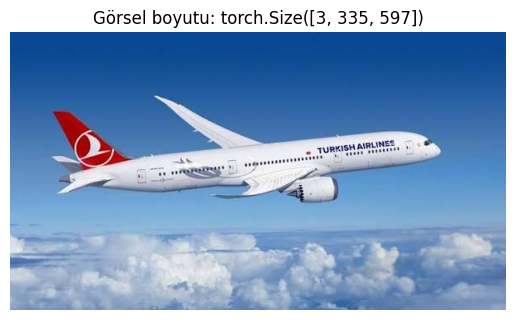

In [54]:
online_image_path = "data/thy.jpg"

# Görseli okurken veri tipini (dtype) doğrudan torch.float32 olarak belirtiyoruz
single_image = torchvision.io.read_image(str(online_image_path)).type(torch.float32)

# Ardından piksel değerlerini 255'e bölerek [0, 1] aralığına normalize ediyoruz
single_image = single_image / 255

# Matplotlib için eksen sırasını (C, H, W) -> (H, W, C) yapıp görseli çizdir
plt.imshow(single_image.permute(1, 2, 0))
plt.title(f"Görsel boyutu: {single_image.shape}")
plt.axis(False)
plt.show()

In [55]:
IMG_SIZE = 224

# Manuel dönüşüm hattını (transform pipeline) oluştur
manual_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    # transforms.ToTensor(),  # Görsel zaten float32 tensör yapılıp 255'e bölündüğü için kapalı tutuyoruz
])

# Görsele boyutlandırma dönüşümünü uygula
single_image = manual_transforms(single_image)
print(single_image.shape)
# torch.Size([3, 224, 224])

# Modelin beklediği batch boyutunu (dim=0) ekle
print(single_image.unsqueeze(dim=0).shape)
# torch.Size([1, 3, 224, 224])

# Batch boyutu eklenmiş tensörü çalışma cihazına (device) taşı
single_image = single_image.unsqueeze(dim=0).to(device)

# Modeli değerlendirme (eval) moduna al ve çıkarım (inference) bağlamında tahmini hesapla
pretrained_vit.eval()
with torch.inference_mode():
    logits = pretrained_vit(single_image)
    probs = torch.softmax(logits, dim=1)
    pred_idx = probs.argmax(dim=1).item()

print("Tahmin edilen sınıf:", class_names[pred_idx])

torch.Size([3, 224, 224])
torch.Size([1, 3, 224, 224])
Tahmin edilen sınıf: airplanes
